# 电池 SOH 迁移学习：MLP 与 Temporal Transformer + MLP

本 notebook 面向“源域 NCA → 目标域 LFP”的迁移学习。读取源域 notebook 保存的
nca_artifacts，在目标域比较四种方案：

- Zero-shot：直接使用源域模型，不使用目标域标签；
- Head-only：冻结特征提取器，只微调回归头；
- Full fine-tune：加载源域权重，微调整个网络；
- Scratch：目标域随机初始化，从头训练。

两类模型均做深度集成：行级 MLP，以及输入历史窗口的 Temporal Transformer + MLP。
请先运行 NCA 源域 notebook 的保存单元格，再修改下一格的 TARGET_DATA_ROOT。迁移阶段会排除 DOD=20% 工况，剩余工况用于 train/val/test。

## 运行建议

1. 将 `SOURCE_ARTIFACT_ROOT`、`TARGET_DATA_ROOT` 改成你的实际路径。
2. 先确认源域产物与目标域特征数量、特征顺序、`seq_len` 一致。
3. 按 notebook 顺序从第一个代码单元运行，不要只运行最后的实验单元。
4. 迁移阶段会先排除配置中的 DOD 工况和手动指定的电池编号；`BATTERIES_PER_CONDITION=1/2/3` 再表示每种剩余 SOC-DOD 工况选择 1/2/3 块互不重复电池，被选中的电池固定为 train。
5. MLP 和 Transformer 的每个 epoch 都会打印 train loss、val loss、backbone/head 学习率；`ReduceLROnPlateau` 根据 val loss 自动降低学习率。
6. 出现错误时先重启 Kernel，再从第一个代码单元重新运行，避免旧定义残留。


In [110]:
# ==================== 0. 导入与配置 ====================
import copy
import random
import re
import warnings
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from matplotlib.colors import BoundaryNorm, ListedColormap
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore", category=UserWarning)


def set_seed(seed=42):
    """统一设置 Python、NumPy 和 PyTorch 的随机种子。"""
    seed = int(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    # 让同一个 seed 的 ensemble 成员尽量可复现。
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


RANDOM_SEED = 42
set_seed(RANDOM_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- 修改这里 ----------
SOURCE_ARTIFACT_ROOT = Path("./nca_artifacts")
TARGET_DATA_ROOT = Path(r"C:\Users\huang\OneDrive\桌面\A123_output_rc_soh_1_300_mixed_conditions")
TARGET_VAL_REMAINING_RATIO = 0.05
TARGET_TEST_REMAINING_RATIO = 0.1
TRANSFER_SCALER_MODE = "source"  # "source" 或 "target_train"
SEQUENCE_UNIT_OVERRIDE = None     # None、"row" 或 "file"
DATA_EXTENSIONS = {".csv", ".txt", ".tsv"}
EXCLUDED_TARGET_DODS = {20,100}     # 迁移阶段完全排除的 DOD 工况（百分比），例如 {20.0}
EXCLUDED_TARGET_CELL_IDS = {"A123_172"}  # 手动完全排除的电池编号，例如 {"A123_189","A123_185","A123_186","A123_207"}

# ---------- SOC-DOD 工况抽样 ----------
# 每种 SOC-DOD 工况选择 K 块互不重复的电池。
BATTERIES_PER_CONDITION = 3
BATTERY_ID_REGEX = r"^(A123_\d+)"
CONDITION_SELECTION_SEED = RANDOM_SEED
STRICT_CONDITION_SELECTION = True
TARGET_SELECTION_OUTPUT = Path("./target_condition_selection")

# ---------- 训练与自适应学习率 ----------
ADAPT_EPOCHS_MLP = 150
ADAPT_EPOCHS_TRANSFORMER = 40
ADAPT_PATIENCE = 10                 # 验证损失长期不改善时提前停止
BATCH_SIZE_MLP = 4096
BATCH_SIZE_TRANSFORMER = 512
VERBOSE_TRAINING = True
TRAIN_SEEDS = [42, 2024, 9999]

# ReduceLROnPlateau：监控 val_loss，而不是 train_loss。
LR_FACTOR = 0.5                     # 触发后 lr 乘以 0.5
LR_PATIENCE = 10                     # 连续多少轮没有明显改善后降 lr
LR_THRESHOLD = 1e-4                 # val_loss 至少改善该数值才算改善
MIN_LR = 1e-6
GRAD_CLIP_NORM = 1.0

# MLP 与 Transformer 共用的训练辅助函数。放在公共配置单元中，
# 因此跳过整个 MLP 章节时，Transformer 仍可独立训练。
def _scheduler(optimizer):
    return torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=LR_FACTOR,
        patience=LR_PATIENCE,
        threshold=LR_THRESHOLD,
        threshold_mode="abs",
        cooldown=1,
        min_lr=MIN_LR,
    )


def _group_lrs(optimizer):
    return [float(group["lr"]) for group in optimizer.param_groups]


def _copy_state_to_cpu(model):
    return {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}


# 迁移学习使用分层学习率：backbone 小，head 大。
MLP_HEAD_ONLY_LR = 1e-3
MLP_BACKBONE_LR = 1e-5
MLP_HEAD_LR = 5e-4
MLP_SCRATCH_LR = 2e-3
TRANSFORMER_HEAD_ONLY_LR = 1e-3
TRANSFORMER_BACKBONE_LR = 1e-5
TRANSFORMER_HEAD_LR = 5e-4
TRANSFORMER_SCRATCH_LR = 2e-4

print(f"PyTorch={torch.__version__} | device={device}")
print(f"自适应学习率: factor={LR_FACTOR}, patience={LR_PATIENCE}, threshold={LR_THRESHOLD}, min_lr={MIN_LR}")


PyTorch=2.13.0+cu126 | device=cuda
自适应学习率: factor=0.5, patience=10, threshold=0.0001, min_lr=1e-06


In [111]:
# ==================== 1. 读取源域权重与预处理器 ====================
MLP_PRE_PATH = SOURCE_ARTIFACT_ROOT / "nca_mlp_pre.joblib"
MLP_CKPT_PATH = SOURCE_ARTIFACT_ROOT / "nca_mlp_ensemble.pt"
TEMPORAL_ROOT = SOURCE_ARTIFACT_ROOT / "temporal_transformer"
TEMPORAL_PRE_PATH = TEMPORAL_ROOT / "nca_temporal_transformer_pre.joblib"
TEMPORAL_CKPT_PATH = TEMPORAL_ROOT / "nca_temporal_transformer_ensemble.pt"
required = [MLP_PRE_PATH, MLP_CKPT_PATH, TEMPORAL_PRE_PATH, TEMPORAL_CKPT_PATH]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError("缺少源域迁移产物，请先运行源域 notebook 保存单元格：\n" + "\n".join(missing))

mlp_pre = joblib.load(MLP_PRE_PATH)
temporal_pre = joblib.load(TEMPORAL_PRE_PATH)

def safe_torch_load(path):
    try: return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError: return torch.load(path, map_location="cpu")

def member_states(checkpoint):
    keys = sorted([k for k in checkpoint if str(k).startswith("member_")],
                  key=lambda x: int(str(x).split("_")[-1]))
    return [checkpoint[k] for k in keys]

mlp_member_states = member_states(safe_torch_load(MLP_CKPT_PATH))
temporal_member_states = member_states(safe_torch_load(TEMPORAL_CKPT_PATH))
OCV_FEATURE = "OCV (V)"
source_features = list(mlp_pre["features"])
temporal_source_features = list(temporal_pre.get("features", source_features))
if OCV_FEATURE in source_features or OCV_FEATURE in temporal_source_features:
    raise ValueError(
        "源域迁移产物仍包含 OCV (V)。请先重新运行去掉 OCV 后的源域 Notebook，"
        "重新生成 nca_artifacts，再运行本 Notebook。"
    )
if source_features != temporal_source_features:
    raise ValueError("MLP 与 Transformer 的源域特征列表不一致。")
FEATURES = source_features; TARGET = mlp_pre["target"]
LOG_TAU_COLS = list(mlp_pre.get("log_tau_cols", ["tau1 (s)", "tau2 (s)"]))
USE_LOG_TAU = bool(mlp_pre.get("use_log_tau", False))
MLP_HIDDEN = tuple(mlp_pre.get("hidden", (128, 64, 32)))
MLP_DROPOUT = float(mlp_pre.get("p_drop", 0.25))
MLP_IN_DIM = int(mlp_pre.get("in_dim", len(FEATURES)))
SEQ_LEN = int(temporal_pre["seq_len"]); SEQ_STRIDE = int(temporal_pre["seq_stride"])
SEQUENCE_UNIT = SEQUENCE_UNIT_OVERRIDE or temporal_pre.get("sequence_unit", "row")
TEMPORAL_D_MODEL = int(temporal_pre.get("d_model", 64))
TEMPORAL_NHEAD = int(temporal_pre.get("nhead", 4))
TEMPORAL_NUM_LAYERS = int(temporal_pre.get("num_layers", 2))
TEMPORAL_DIM_FF = int(temporal_pre.get("dim_ff", 128))
TEMPORAL_DROPOUT = float(temporal_pre.get("p_drop", 0.10))
source_x_scaler = mlp_pre["x_scaler"]; source_y_scaler = mlp_pre["y_scaler"]
source_seq_scaler = temporal_pre["seq_scaler"]; source_seq_y_scaler = temporal_pre["seq_y_scaler"]
print(f"源域特征: {FEATURES}")
print(f"MLP 成员={len(mlp_member_states)} | Transformer 成员={len(temporal_member_states)}")
print(f"时序: unit={SEQUENCE_UNIT}, seq_len={SEQ_LEN}, stride={SEQ_STRIDE}")

源域特征: ['R0 (Ohm)', 'R1 (Ohm)', 'tau1 (s)', 'R2 (Ohm)', 'tau2 (s)', 'Temperature (°C)']
MLP 成员=3 | Transformer 成员=3
时序: unit=row, seq_len=16, stride=4


In [112]:
# ==================== 2. 读取目标域数据 + 排除 DOD/电池 + 抽取电池 ====================
TIME_RE = re.compile(r"(\d{8})_(\d{6})")

def normalize_col(name):
    return re.sub(r"[^a-z0-9]+", "", str(name).lower().replace("°", ""))

def canonicalize_columns(frame):
    frame = frame.copy()
    frame.columns = frame.columns.astype(str).str.replace("\ufeff", "", regex=False).str.strip()
    normalized = {normalize_col(c): c for c in frame.columns}
    for name in list(dict.fromkeys(FEATURES + [TARGET, "segment_id"])):
        if name not in frame.columns and normalize_col(name) in normalized:
            frame[name] = frame[normalized[normalize_col(name)]]
    return frame

def parse_time(name):
    m = TIME_RE.search(str(name))
    return datetime.strptime(f"{m.group(1)}{m.group(2)}", "%Y%m%d%H%M%S") if m else None

def extract_marker_value(text, marker_pattern):
    """识别 70SOC、SOC70、60DOD、DOD60 等文件夹命名。"""
    patterns = [
        rf"([0-9]+(?:\.[0-9]+)?)[ _-]*(?:{marker_pattern})",
        rf"(?:{marker_pattern})[^0-9]*([0-9]+(?:\.[0-9]+)?)",
    ]
    for pattern in patterns:
        match = re.search(pattern, str(text), flags=re.IGNORECASE)
        if match is not None:
            return float(match.group(1))
    return None

def parse_condition_name(text):
    soc = extract_marker_value(text, r"soc|state[ _-]?of[ _-]?charge")
    dod = extract_marker_value(text, r"dod|depth[ _-]?of[ _-]?discharge")
    if soc is None or dod is None:
        return None
    return round(soc, 6), round(dod, 6)

def find_condition_component(path, root):
    """寻找最近的 SOC-DOD 文件夹或文件名。"""
    rel_parts = path.relative_to(root).parts
    for index in range(len(rel_parts) - 1, -1, -1):
        component = Path(rel_parts[index]).stem if index == len(rel_parts) - 1 else rel_parts[index]
        has_soc = re.search(r"soc|state[ _-]?of[ _-]?charge", component, re.IGNORECASE)
        has_dod = re.search(r"dod|depth[ _-]?of[ _-]?discharge", component, re.IGNORECASE)
        if has_soc and has_dod and parse_condition_name(component) is not None:
            return component
    return None

def battery_id_from_condition_component(component):
    """从 A123_007_70SOC_60DOD 提取 A123_007。"""
    if BATTERY_ID_REGEX:
        explicit_match = re.search(BATTERY_ID_REGEX, str(component), flags=re.IGNORECASE)
        if explicit_match is not None:
            return explicit_match.group(1)
    marker = re.search(
        r"(?:[0-9]+(?:\.[0-9]+)?[ _-]*(?:soc|state[ _-]?of[ _-]?charge)|"
        r"(?:soc|state[ _-]?of[ _-]?charge)[ _-]*[0-9]+(?:\.[0-9]+)?)",
        str(component),
        flags=re.IGNORECASE,
    )
    if marker is None:
        return str(component)
    return str(component)[: marker.start()].rstrip("_ -") or str(component)

def condition_label(soc, dod):
    return f"SOC={soc:g}% | DOD={dod:g}%"

def load_target_batteries(root):
    root = Path(root)
    if not root.exists():
        raise FileNotFoundError(f"TARGET_DATA_ROOT 不存在：{root.resolve()}")
    frames, skipped = [], []
    file_order_by_component = {}
    condition_dirs = sorted([p for p in root.iterdir() if p.is_dir()])
    scan_roots = [(p, p.name) for p in condition_dirs]
    direct_files = [p for p in root.iterdir() if p.is_file() and p.suffix.lower() in DATA_EXTENSIONS]
    if direct_files:
        scan_roots.append((root, None))

    for scan_root, fixed_component in scan_roots:
        files = sorted(
            [p for p in scan_root.rglob("*") if p.is_file() and p.suffix.lower() in DATA_EXTENSIONS],
            key=lambda p: (parse_time(p.name) is None, parse_time(p.name) or p.name, str(p)),
        )
        for path in files:
            # 对用户的目录结构，工况只从 LFP 根目录下的一级文件夹名读取。
            # 内部文件夹/文件名不会再生成新的电池 ID。
            component = fixed_component or find_condition_component(path, root)
            if component is None:
                skipped.append((str(path.relative_to(root)), "一级路径中未识别到 SOC-DOD 工况"))
                continue
            soc, dod = parse_condition_name(component)
            battery_id = battery_id_from_condition_component(component)
            file_order = file_order_by_component.get(component, 0)
            file_order_by_component[component] = file_order + 1
            try:
                frame = canonicalize_columns(pd.read_csv(path, sep=None, engine="python"))
            except Exception as exc:
                skipped.append((str(path.relative_to(root)), f"读取失败：{exc}"))
                continue
            frame["cell_id"] = battery_id
            frame["condition_soc"] = soc
            frame["condition_dod"] = dod
            frame["condition_key"] = condition_label(soc, dod)
            frame["condition_folder"] = component
            frame["file_order"] = file_order
            frame["source_file"] = str(path.relative_to(root))
            frame["file_time"] = parse_time(path.name)
            if "segment_id" not in frame.columns:
                frame["segment_id"] = np.arange(len(frame))
            frames.append(frame)
    if not frames:
        details = "\n".join(f"- {path}: {reason}" for path, reason in skipped[:10])
        raise RuntimeError(
            "没有读取到带有 SOC-DOD 工况文件夹的数据。示例命名应类似 A123_007_70SOC_60DOD。\n"
            + details
        )
    return pd.concat(frames, ignore_index=True), skipped

def select_condition_batteries(frame):
    """每种 SOC-DOD 工况分配 K 块互不重复的电池。"""
    availability = frame[["cell_id", "condition_soc", "condition_dod", "condition_key"]].drop_duplicates()
    grouped = availability.groupby(["condition_soc", "condition_dod", "condition_key"], sort=True)
    rng = np.random.default_rng(CONDITION_SELECTION_SEED)
    condition_groups = []
    for key, group in grouped:
        candidates = sorted(group["cell_id"].astype(str).unique().tolist())
        rng.shuffle(candidates)
        condition_groups.append({"key": key, "group": group, "candidates": candidates})
    condition_groups.sort(key=lambda item: len(item["candidates"]))

    slots = [
        (condition_index, slot_index)
        for condition_index in range(len(condition_groups))
        for slot_index in range(BATTERIES_PER_CONDITION)
    ]
    battery_to_slot, slot_to_battery = {}, {}

    def try_match(slot, visited):
        condition_index, _ = slot
        for battery_id in condition_groups[condition_index]["candidates"]:
            if battery_id in visited:
                continue
            visited.add(battery_id)
            previous_slot = battery_to_slot.get(battery_id)
            if previous_slot is None or try_match(previous_slot, visited):
                battery_to_slot[battery_id] = slot
                slot_to_battery[slot] = battery_id
                return True
        return False

    unmatched = [slot for slot in slots if not try_match(slot, set())]
    required_total = len(condition_groups) * BATTERIES_PER_CONDITION
    if unmatched and STRICT_CONDITION_SELECTION:
        raise ValueError(
            f"无法为 {len(condition_groups)} 种 SOC-DOD 工况分配 {required_total} 块互不重复的电池。"
            "请减少 BATTERIES_PER_CONDITION，或检查电池文件夹命名和可用电池数量。"
        )

    selected_records, diagnostics = [], []
    for condition_index, item in enumerate(condition_groups):
        soc, dod, condition_key = item["key"]
        chosen = sorted(
            slot_to_battery.get((condition_index, slot_index))
            for slot_index in range(BATTERIES_PER_CONDITION)
            if slot_to_battery.get((condition_index, slot_index)) is not None
        )
        for cell_id in chosen:
            selected_records.append(
                {
                    "cell_id": cell_id,
                    "condition_soc": float(soc),
                    "condition_dod": float(dod),
                    "condition_key": condition_key,
                }
            )
        diagnostics.append(
            {
                "condition_key": condition_key,
                "available_batteries": len(item["candidates"]),
                "requested_batteries": BATTERIES_PER_CONDITION,
                "selected_batteries": len(chosen),
                "selected_ids": ", ".join(chosen),
            }
        )
    selected = pd.DataFrame(
        selected_records,
        columns=["cell_id", "condition_soc", "condition_dod", "condition_key"],
    )
    return selected, pd.DataFrame(diagnostics), availability

df_target_all, skipped_target_files = load_target_batteries(TARGET_DATA_ROOT)
excluded_dods = {
    round(float(value), 6)
    for value in EXCLUDED_TARGET_DODS
}
excluded_cell_ids = {
    str(value).strip()
    for value in EXCLUDED_TARGET_CELL_IDS
    if str(value).strip()
}

raw_target_rows = len(df_target_all)
raw_target_cell_count = int(df_target_all["cell_id"].astype(str).nunique())
raw_target_condition_count = int(
    df_target_all["condition_key"].nunique()
)

excluded_dod_mask = (
    df_target_all["condition_dod"].round(6).isin(excluded_dods)
    if excluded_dods
    else pd.Series(False, index=df_target_all.index)
)
excluded_cell_mask = (
    df_target_all["cell_id"].astype(str).str.strip().isin(excluded_cell_ids)
    if excluded_cell_ids
    else pd.Series(False, index=df_target_all.index)
)
excluded_mask = excluded_dod_mask | excluded_cell_mask
excluded_condition_keys = sorted(
    df_target_all.loc[excluded_mask, "condition_key"].dropna().astype(str).unique().tolist()
)
excluded_cell_ids_present = sorted(
    df_target_all.loc[excluded_cell_mask, "cell_id"].astype(str).str.strip().unique().tolist()
)
df_target = df_target_all.loc[~excluded_mask].copy()
if excluded_dods:
    print(f"排除 DOD 工况: {sorted(excluded_dods)}")
else:
    print("本轮不排除任何 DOD 工况")
if excluded_cell_ids:
    print(f"排除电池编号: {sorted(excluded_cell_ids)} | 数据中命中: {excluded_cell_ids_present}")
else:
    print("本轮不排除任何电池编号")

numeric_cols = list(dict.fromkeys(FEATURES + [TARGET]))
missing_cols = [c for c in numeric_cols if c not in df_target.columns]
if missing_cols:
    raise KeyError(f"目标域缺少必要列：{missing_cols}")
for col in numeric_cols:
    df_target[col] = pd.to_numeric(
        df_target[col].astype(str).str.strip().str.replace(",", ".", regex=False),
        errors="coerce",
    )
if USE_LOG_TAU:
    for col in LOG_TAU_COLS:
        if (df_target[col] <= 0).any():
            raise ValueError(f"{col} 含非正数，无法 log 变换")
        df_target[col] = np.log(df_target[col])

df_target = df_target.dropna(subset=numeric_cols).reset_index(drop=True)
if df_target["condition_dod"].round(6).isin(excluded_dods).any():
    raise RuntimeError("目标域筛选失败：剩余数据中仍包含被排除的 DOD 工况。")
if df_target["cell_id"].astype(str).str.strip().isin(excluded_cell_ids).any():
    raise RuntimeError("目标域筛选失败：剩余数据中仍包含手动排除的电池编号。")
remaining_target_dods = sorted(df_target["condition_dod"].round(6).unique().tolist())
folder_mapping = df_target[["condition_folder", "cell_id", "condition_key"]].drop_duplicates()
print(f"已排除 DOD={sorted(excluded_dods)}% | 排除工况={excluded_condition_keys} | 排除样本={int(excluded_mask.sum()):,}")
print(f"已排除电池={excluded_cell_ids_present} | 原始电池数={raw_target_cell_count} | 剩余电池数={df_target['cell_id'].nunique()}")
print(f"剩余 DOD={remaining_target_dods}% | 剩余工况={df_target['condition_key'].nunique()} / 原始工况={raw_target_condition_count}")
print(f"工况文件夹数={folder_mapping['condition_folder'].nunique()} | 文件夹解析后的电池 ID 数={folder_mapping['cell_id'].nunique()}")
display(folder_mapping.head(20))
selected_assignments, selection_diagnostics, condition_availability = select_condition_batteries(df_target)
selection_keys = ["cell_id", "condition_soc", "condition_dod", "condition_key"]
selected_train_cells = np.sort(selected_assignments["cell_id"].astype(str).unique())
selected_train_data = df_target.merge(selected_assignments[selection_keys], on=selection_keys, how="inner")
all_target_cells = set(df_target["cell_id"].astype(str).unique())
remaining_holdout_cells = sorted(all_target_cells - set(selected_train_cells))
holdout_data = df_target[df_target["cell_id"].astype(str).isin(remaining_holdout_cells)].copy()
data = pd.concat([selected_train_data, holdout_data], ignore_index=True)
if data.empty or selected_train_data.empty:
    raise RuntimeError("工况抽样后没有可用的 train 目标域样本。")
if data["condition_dod"].round(6).isin(excluded_dods).any():
    raise RuntimeError("train/holdout 数据中仍包含被排除的 DOD 工况。")

TARGET_SELECTION_OUTPUT.mkdir(parents=True, exist_ok=True)
selected_assignments.to_csv(TARGET_SELECTION_OUTPUT / "selected_condition_batteries.csv", index=False, encoding="utf-8-sig")
selection_diagnostics.to_csv(TARGET_SELECTION_OUTPUT / "selection_diagnostics.csv", index=False, encoding="utf-8-sig")
condition_availability.to_csv(TARGET_SELECTION_OUTPUT / "condition_availability.csv", index=False, encoding="utf-8-sig")
folder_mapping.to_csv(TARGET_SELECTION_OUTPUT / "folder_to_battery_mapping.csv", index=False, encoding="utf-8-sig")
if skipped_target_files:
    pd.DataFrame(skipped_target_files, columns=["source_file", "reason"]).to_csv(
        TARGET_SELECTION_OUTPUT / "skipped_files.csv", index=False, encoding="utf-8-sig"
    )

expected_batteries = selection_diagnostics["condition_key"].nunique() * BATTERIES_PER_CONDITION
selected_batteries = selected_train_data["cell_id"].nunique()
if STRICT_CONDITION_SELECTION and selected_batteries != expected_batteries:
    raise RuntimeError("抽样后的不同电池数与工况数 × 每工况电池数不一致。")
X_target_raw = data[FEATURES].to_numpy(dtype=np.float32)
y_target = data[TARGET].to_numpy(dtype=np.float32)
target_groups = data["cell_id"].to_numpy()
print(f"筛选前目标域样本={raw_target_rows:,} | 筛选后样本={len(df_target):,} | 工况={selection_diagnostics['condition_key'].nunique()} 种")
print(f"后续 train/val/test 仅使用剩余 DOD={remaining_target_dods}% 工况，并排除电池={sorted(excluded_cell_ids)}")
print(f"每种工况电池数={BATTERIES_PER_CONDITION} | 筛选后不同电池={selected_batteries} | 理论数量={expected_batteries}")
print(f"train 固定电池={selected_batteries} | 剩余 holdout 电池={len(remaining_holdout_cells)}")
print(f"目标域总样本={len(data):,} | 总电池数={data['cell_id'].nunique()}")
display(selection_diagnostics)


排除 DOD 工况: [20.0, 100.0]
排除电池编号: ['A123_172'] | 数据中命中: ['A123_172']
已排除 DOD=[20.0, 100.0]% | 排除工况=['SOC=10% | DOD=20%', 'SOC=30% | DOD=20%', 'SOC=30% | DOD=60%', 'SOC=50% | DOD=100%', 'SOC=50% | DOD=20%', 'SOC=70% | DOD=20%', 'SOC=90% | DOD=20%'] | 排除样本=1,594,394
已排除电池=['A123_172'] | 原始电池数=202 | 剩余电池数=93
剩余 DOD=[40.0, 60.0, 80.0]% | 剩余工况=7 / 原始工况=13
工况文件夹数=1611 | 文件夹解析后的电池 ID 数=93


,condition_folder,cell_id,condition_key
0,A123_007_70SOC_60DOD,A123_007,SOC=70% | DOD=60%
8110,A123_008_70SOC_60DOD,A123_008,SOC=70% | DOD=60%
15799,A123_009_70SOC_60DOD,A123_009,SOC=70% | DOD=60%
23854,A123_010_70SOC_60DOD,A123_010,SOC=70% | DOD=60%
31913,A123_011_30SOC_60DOD,A123_011,SOC=30% | DOD=60%
38862,A123_016_70SOC_60DOD,A123_016,SOC=70% | DOD=60%
46980,A123_017_70SOC_60DOD,A123_017,SOC=70% | DOD=60%
55095,A123_018_70SOC_60DOD,A123_018,SOC=70% | DOD=60%
63214,A123_019_70SOC_60DOD,A123_019,SOC=70% | DOD=60%
71330,A123_020_50SOC_60DOD,A123_020,SOC=50% | DOD=60%


筛选前目标域样本=2,756,268 | 筛选后样本=1,161,874 | 工况=7 种
后续 train/val/test 仅使用剩余 DOD=[40.0, 60.0, 80.0]% 工况，并排除电池=['A123_172']
每种工况电池数=3 | 筛选后不同电池=21 | 理论数量=21
train 固定电池=21 | 剩余 holdout 电池=72
目标域总样本=1,161,874 | 总电池数=93


,condition_key,available_batteries,requested_batteries,selected_batteries,selected_ids
0,SOC=50% | DOD=80%,7,3,3,"A123_164, A123_202, A123_212"
1,SOC=30% | DOD=40%,11,3,3,"A123_099, A123_176, A123_196"
2,SOC=50% | DOD=40%,11,3,3,"A123_133, A123_137, A123_179"
3,SOC=50% | DOD=60%,11,3,3,"A123_020, A123_161, A123_237"
4,SOC=70% | DOD=40%,12,3,3,"A123_074, A123_123, A123_238"
5,SOC=70% | DOD=60%,18,3,3,"A123_009, A123_018, A123_209"
6,SOC=30% | DOD=60%,23,3,3,"A123_076, A123_146, A123_231"


In [113]:
# ==================== 3. 固定工况抽样电池为 train + 从剩余电池抽取 val/test ====================
def make_target_split(groups, selected_train_cells, val_ratio, test_ratio, seed=42):
    groups = np.asarray(groups).astype(str)
    all_cells = np.unique(groups)
    selected_train_cells = np.unique(np.asarray(selected_train_cells).astype(str))
    missing_train_cells = sorted(set(selected_train_cells) - set(all_cells))
    if missing_train_cells:
        raise ValueError(f"工况抽样得到的 train 电池不在目标数据中：{missing_train_cells}")
    if val_ratio < 0 or test_ratio < 0 or val_ratio + test_ratio > 1:
        raise ValueError("TARGET_VAL_REMAINING_RATIO 和 TARGET_TEST_REMAINING_RATIO 必须非负且总和不超过 1。")

    remaining_cells = np.array(sorted(set(all_cells) - set(selected_train_cells)), dtype=str)
    rng = np.random.default_rng(seed)
    rng.shuffle(remaining_cells)
    n_val = int(round(len(remaining_cells) * val_ratio))
    n_test = int(round(len(remaining_cells) * test_ratio))
    if n_val + n_test > len(remaining_cells):
        raise ValueError("剩余电池数量不足以完成 val/test 比例划分。")

    test_cells = np.sort(remaining_cells[:n_test])
    val_cells = np.sort(remaining_cells[n_test:n_test + n_val])
    train_cells = np.sort(selected_train_cells)
    train_idx = np.where(np.isin(groups, train_cells))[0]
    val_idx = np.where(np.isin(groups, val_cells))[0]
    test_idx = np.where(np.isin(groups, test_cells))[0]
    return np.sort(train_idx), np.sort(val_idx), np.sort(test_idx), train_cells, val_cells, test_cells

train_idx, val_idx, test_idx, target_train_cells, target_val_cells, target_test_cells = make_target_split(
    target_groups,
    selected_train_cells,
    TARGET_VAL_REMAINING_RATIO,
    TARGET_TEST_REMAINING_RATIO,
    RANDOM_SEED,
)
train_cells = set(target_groups[train_idx]); val_cells = set(target_groups[val_idx]); test_cells = set(target_groups[test_idx])
assert train_cells == set(selected_train_cells)
assert train_cells.isdisjoint(val_cells) and train_cells.isdisjoint(test_cells) and val_cells.isdisjoint(test_cells)
for split_name, split_idx in {"train": train_idx, "val": val_idx, "test": test_idx}.items():
    if data.iloc[split_idx]["condition_dod"].round(6).isin(excluded_dods).any():
        raise RuntimeError(f"{split_name} 划分中包含被排除的 DOD 工况。")
    if data.iloc[split_idx]["cell_id"].astype(str).str.strip().isin(excluded_cell_ids).any():
        raise RuntimeError(f"{split_name} 划分中包含手动排除的电池编号。")
X_train_raw, y_train = X_target_raw[train_idx], y_target[train_idx]
X_val_raw, y_val = X_target_raw[val_idx], y_target[val_idx]
X_test_raw, y_test = X_target_raw[test_idx], y_target[test_idx]

if TRANSFER_SCALER_MODE == "source":
    transfer_x_scaler, transfer_y_scaler = source_x_scaler, source_y_scaler
elif TRANSFER_SCALER_MODE == "target_train":
    transfer_x_scaler = StandardScaler().fit(X_train_raw); transfer_y_scaler = StandardScaler().fit(y_train[:, None])
else: raise ValueError("TRANSFER_SCALER_MODE 必须是 'source' 或 'target_train'")
zero_shot_y_scaler = source_y_scaler
scratch_x_scaler = StandardScaler().fit(X_train_raw); scratch_y_scaler = StandardScaler().fit(y_train[:, None])

def scale_2d(scaler, values): return scaler.transform(values).astype(np.float32)
X_train_transfer = scale_2d(transfer_x_scaler, X_train_raw); X_val_transfer = scale_2d(transfer_x_scaler, X_val_raw); X_test_transfer = scale_2d(transfer_x_scaler, X_test_raw)
yt_transfer = transfer_y_scaler.transform(y_train[:, None]).ravel().astype(np.float32); yv_transfer = transfer_y_scaler.transform(y_val[:, None]).ravel().astype(np.float32)
X_train_scratch = scale_2d(scratch_x_scaler, X_train_raw); X_val_scratch = scale_2d(scratch_x_scaler, X_val_raw); X_test_scratch = scale_2d(scratch_x_scaler, X_test_raw)
yt_scratch = scratch_y_scaler.transform(y_train[:, None]).ravel().astype(np.float32); yv_scratch = scratch_y_scaler.transform(y_val[:, None]).ravel().astype(np.float32)

def to_loader(Xs, ys, batch_size, shuffle=False):
    ds = TensorDataset(torch.as_tensor(Xs, dtype=torch.float32), torch.as_tensor(ys, dtype=torch.float32).view(-1, 1))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

def evaluate(y_true, y_pred, name):
    out = {"mae": float(mean_absolute_error(y_true, y_pred)), "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))), "r2": float(r2_score(y_true, y_pred))}
    print(f"{name:32s} | MAE={out['mae']:.4f} | RMSE={out['rmse']:.4f} | R²={out['r2']:.4f}")
    return out

print(f"train 固定工况电池={len(train_cells)} | val={len(val_cells)} | test={len(test_cells)}")
print(f"剩余电池={len(set(target_groups) - train_cells)} | val 比例={TARGET_VAL_REMAINING_RATIO} | test 比例={TARGET_TEST_REMAINING_RATIO}")
print(f"scaler={TRANSFER_SCALER_MODE} | train cells={sorted(target_train_cells.tolist())}")


train 固定工况电池=21 | val=4 | test=7
剩余电池=72 | val 比例=0.05 | test 比例=0.1
scaler=source | train cells=['A123_009', 'A123_018', 'A123_020', 'A123_074', 'A123_076', 'A123_099', 'A123_123', 'A123_133', 'A123_137', 'A123_146', 'A123_161', 'A123_164', 'A123_176', 'A123_179', 'A123_196', 'A123_202', 'A123_209', 'A123_212', 'A123_231', 'A123_237', 'A123_238']


## 4. MLP 迁移学习

复用源域的 feature + head 结构。Head-only 时冻结参数，并将特征层设为 eval，避免 BatchNorm 的 running statistics 和 Dropout 状态被目标域训练改变。

In [114]:
# ==================== 4.1 MLP 结构、训练与预测 ====================
class SOHNet(nn.Module):
    def __init__(self, in_dim, hidden, p_drop):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Linear(in_dim, hidden[0]), nn.BatchNorm1d(hidden[0]), nn.GELU(), nn.Dropout(p_drop),
            nn.Linear(hidden[0], hidden[1]), nn.BatchNorm1d(hidden[1]), nn.GELU(), nn.Dropout(p_drop),
            nn.Linear(hidden[1], hidden[2]), nn.BatchNorm1d(hidden[2]), nn.GELU(),
        )
        self.head = nn.Linear(hidden[2], 1)

    def forward(self, x):
        return self.head(self.feature(x))


def train_mlp_one(
    seed,
    Xtr,
    ytr,
    Xv,
    yv,
    init_state=None,
    only_head=False,
    epochs=50,
    lr=None,
    head_lr=None,
    backbone_lr=None,
    weight_decay=3e-4,
    patience=10,
    verbose=True,
):
    """训练一个 MLP 成员，并为 head/backbone 分别使用自适应学习率。"""
    set_seed(seed)
    model = SOHNet(MLP_IN_DIM, MLP_HIDDEN, MLP_DROPOUT).to(device)
    if init_state is not None:
        model.load_state_dict(init_state)

    # 每次新建模型时显式恢复可训练状态，避免同一进程内状态串扰。
    for parameter in model.parameters():
        parameter.requires_grad = True
    if only_head:
        for parameter in model.feature.parameters():
            parameter.requires_grad = False

    if lr is not None:
        head_lr = float(lr) if head_lr is None else float(head_lr)
        backbone_lr = float(lr) if backbone_lr is None else float(backbone_lr)
    head_lr = float(head_lr if head_lr is not None else MLP_HEAD_LR)
    backbone_lr = float(backbone_lr if backbone_lr is not None else MLP_BACKBONE_LR)

    if only_head:
        parameter_groups = [{"params": list(model.head.parameters()), "lr": head_lr, "name": "head"}]
    else:
        parameter_groups = [
            {"params": list(model.feature.parameters()), "lr": backbone_lr, "name": "backbone"},
            {"params": list(model.head.parameters()), "lr": head_lr, "name": "head"},
        ]
    optimizer = torch.optim.AdamW(parameter_groups, weight_decay=weight_decay)
    scheduler = _scheduler(optimizer)
    loss_fn = nn.MSELoss()
    train_loader = to_loader(Xtr, ytr, BATCH_SIZE_MLP, True)
    val_loader = to_loader(Xv, yv, BATCH_SIZE_MLP, False)
    if len(train_loader.dataset) == 0 or len(val_loader.dataset) == 0:
        raise ValueError("MLP 训练集和验证集都必须至少包含 1 个样本。")

    best_loss = float("inf")
    best_state = None
    bad_epochs = 0
    history = {
        "train_loss": [],
        "val_loss": [],
        "lr": [],
        "lr_backbone": [],
        "lr_head": [],
    }

    for epoch in range(1, int(epochs) + 1):
        model.train()
        if only_head:
            # 冻结 BatchNorm 的 running statistics，避免 head-only 仍改变 backbone 状态。
            model.feature.eval()
        train_loss_sum = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = loss_fn(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            optimizer.step()
            train_loss_sum += float(loss.item()) * len(xb)
        train_loss = train_loss_sum / len(train_loader.dataset)

        model.eval()
        val_loss_sum = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_loss_sum += float(loss_fn(model(xb), yb).item()) * len(xb)
        val_loss = val_loss_sum / len(val_loader.dataset)

        # 这组 lr 是本 epoch 实际使用的 lr。
        used_lrs = _group_lrs(optimizer)
        scheduler.step(val_loss)
        next_lrs = _group_lrs(optimizer)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["lr"].append(used_lrs[-1])
        history["lr_head"].append(used_lrs[-1])
        history["lr_backbone"].append(used_lrs[0] if len(used_lrs) > 1 else 0.0)

        if verbose:
            if len(used_lrs) > 1:
                lr_text = f"lr_backbone={used_lrs[0]:.3e} lr_head={used_lrs[-1]:.3e}"
            else:
                lr_text = f"lr_head={used_lrs[-1]:.3e}"
            changed = ""
            if next_lrs != used_lrs:
                changed = " | next_lr=" + ",".join(f"{value:.3e}" for value in next_lrs)
            print(
                f"  epoch={epoch:3d} train_loss={train_loss:.6f} "
                f"val_loss={val_loss:.6f} {lr_text}{changed}"
            )

        if val_loss < best_loss - LR_THRESHOLD:
            best_loss = val_loss
            bad_epochs = 0
            best_state = _copy_state_to_cpu(model)
        else:
            bad_epochs += 1
            if bad_epochs >= int(patience):
                if verbose:
                    print(f"  Early stopping at epoch {epoch}; best_val_loss={best_loss:.6f}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.history = history
    return model


def build_mlp(state):
    model = SOHNet(MLP_IN_DIM, MLP_HIDDEN, MLP_DROPOUT).to(device)
    model.load_state_dict(state)
    return model


def mlp_predict(models, Xs, y_scaler, batch_size=None):
    """分批推理，避免测试集很大时一次性占满 GPU/内存。"""
    if not models:
        raise ValueError("models 不能为空。")
    batch_size = int(batch_size or BATCH_SIZE_MLP)
    loader = DataLoader(torch.as_tensor(Xs, dtype=torch.float32), batch_size=batch_size, shuffle=False)
    predictions = [[] for _ in models]
    for model in models:
        model.eval()
    with torch.no_grad():
        for xb in loader:
            xb = xb.to(device)
            for index, model in enumerate(models):
                predictions[index].append(model(xb).cpu().numpy().ravel())
    scaled_predictions = [np.concatenate(chunks) for chunks in predictions]
    predictions = [y_scaler.inverse_transform(values[:, None]).ravel() for values in scaled_predictions]
    stacked = np.stack(predictions)
    return stacked.mean(axis=0), stacked.std(axis=0)


In [115]:
# ==================== 4.2 MLP 四组实验 ====================
def run_mlp(mode):
    if mode == "zero_shot":
        models = [build_mlp(state) for state in mlp_member_states]
        x_test, scaler = X_test_transfer, zero_shot_y_scaler
    elif mode in {"head_only", "full_fine_tune"}:
        models = []
        seeds = list(mlp_pre.get("seeds", TRAIN_SEEDS))[:len(mlp_member_states)]
        for index, (seed, state) in enumerate(zip(seeds, mlp_member_states), start=1):
            print(f"\nMLP {mode} | member {index}/{len(mlp_member_states)}")
            if mode == "head_only":
                kwargs = {"only_head": True, "head_lr": MLP_HEAD_ONLY_LR}
            else:
                kwargs = {
                    "only_head": False,
                    "backbone_lr": MLP_BACKBONE_LR,
                    "head_lr": MLP_HEAD_LR,
                }
            models.append(
                train_mlp_one(
                    int(seed),
                    X_train_transfer,
                    yt_transfer,
                    X_val_transfer,
                    yv_transfer,
                    init_state=state,
                    epochs=ADAPT_EPOCHS_MLP,
                    patience=ADAPT_PATIENCE,
                    verbose=VERBOSE_TRAINING,
                    **kwargs,
                )
            )
        x_test, scaler = X_test_transfer, transfer_y_scaler
    elif mode == "scratch":
        models = []
        for index, seed in enumerate(TRAIN_SEEDS[:len(mlp_member_states)], start=1):
            print(f"\nMLP scratch | member {index}/{len(mlp_member_states)}")
            models.append(
                train_mlp_one(
                    seed,
                    X_train_scratch,
                    yt_scratch,
                    X_val_scratch,
                    yv_scratch,
                    epochs=ADAPT_EPOCHS_MLP,
                    lr=MLP_SCRATCH_LR,
                    patience=ADAPT_PATIENCE,
                    verbose=VERBOSE_TRAINING,
                )
            )
        x_test, scaler = X_test_scratch, scratch_y_scaler
    else:
        raise ValueError(f"未知 MLP 模式：{mode}")

    mean, std = mlp_predict(models, x_test, scaler)
    metrics = evaluate(y_test, mean, f"MLP / {mode}")
    metrics["uncertainty_mean"] = float(std.mean())
    return {
        "models": models,
        "x_scaler": scratch_x_scaler if mode == "scratch" else transfer_x_scaler,
        "y_scaler": scaler,
        "mean": mean,
        "battery_ids": target_groups[test_idx].astype(str).copy(),
        "std": std,
        "metrics": metrics,
        "histories": [getattr(model, "history", None) for model in models],
    }


MLP_MODES = ["zero_shot", "head_only", "full_fine_tune", "scratch"]
mlp_results = {mode: run_mlp(mode) for mode in MLP_MODES}
mlp_summary = pd.DataFrame({mode: result["metrics"] for mode, result in mlp_results.items()}).T
print(mlp_summary.round(4).to_string())


MLP / zero_shot                  | MAE=4.8827 | RMSE=6.0329 | R²=-0.1456

MLP head_only | member 1/3
  epoch=  1 train_loss=0.348609 val_loss=0.353146 lr_head=1.000e-03
  epoch=  2 train_loss=0.255611 val_loss=0.311360 lr_head=1.000e-03
  epoch=  3 train_loss=0.224356 val_loss=0.294557 lr_head=1.000e-03
  epoch=  4 train_loss=0.204688 val_loss=0.283654 lr_head=1.000e-03
  epoch=  5 train_loss=0.190805 val_loss=0.273222 lr_head=1.000e-03
  epoch=  6 train_loss=0.180614 val_loss=0.264590 lr_head=1.000e-03
  epoch=  7 train_loss=0.172892 val_loss=0.259149 lr_head=1.000e-03
  epoch=  8 train_loss=0.166837 val_loss=0.252234 lr_head=1.000e-03
  epoch=  9 train_loss=0.161868 val_loss=0.246504 lr_head=1.000e-03
  epoch= 10 train_loss=0.157636 val_loss=0.242745 lr_head=1.000e-03
  epoch= 11 train_loss=0.153888 val_loss=0.239977 lr_head=1.000e-03
  epoch= 12 train_loss=0.150474 val_loss=0.237852 lr_head=1.000e-03
  epoch= 13 train_loss=0.147367 val_loss=0.236515 lr_head=1.000e-03
  epoch= 14 tra

## 5. Temporal Transformer + MLP

窗口只在已完成电池级划分的 train/val/test 数据内部生成。Transformer 的 input_proj + encoder 是时序特征提取器，最后的 MLP 是回归头。

In [116]:
# ==================== 5.1 时序窗口与 scaler ====================
n_features = len(FEATURES)

def prepare_steps(frame, unit=SEQUENCE_UNIT):
    frame = frame.copy(); frame["segment_id_num"] = pd.to_numeric(frame["segment_id"], errors="coerce")
    if frame["segment_id_num"].isna().any(): raise ValueError("segment_id 存在无法转换为数字的值")
    frame = frame.sort_values(["cell_id", "file_order", "segment_id_num"], kind="stable")
    if unit == "row": return frame
    if unit != "file": raise ValueError("SEQUENCE_UNIT 必须是 'row' 或 'file'")
    agg = {c: "mean" for c in FEATURES + [TARGET]}
    return frame.groupby(["cell_id", "file_order", "source_file"], as_index=False, sort=False).agg(agg).sort_values(["cell_id", "file_order"], kind="stable")

def make_windows(frame, seq_len=SEQ_LEN, stride=SEQ_STRIDE):
    steps = prepare_steps(frame); Xs, ys, cells = [], [], []
    for cell, g in steps.groupby("cell_id", sort=False):
        values, targets = g[FEATURES].to_numpy(np.float32), g[TARGET].to_numpy(np.float32)
        for start in range(0, max(0, len(values) - seq_len + 1), stride):
            end = start + seq_len; Xs.append(values[start:end]); ys.append(targets[start:end].mean()); cells.append(cell)
    if not Xs: raise RuntimeError(f"没有生成窗口；请保证每块电池至少有 {seq_len} 个时间步")
    return np.stack(Xs).astype(np.float32), np.asarray(ys, np.float32), np.asarray(cells)

X_seq_train_raw, y_seq_train, seq_groups_train = make_windows(data.iloc[train_idx])
X_seq_val_raw, y_seq_val, seq_groups_val = make_windows(data.iloc[val_idx])
X_seq_test_raw, y_seq_test, seq_groups_test = make_windows(data.iloc[test_idx])

if TRANSFER_SCALER_MODE == "source":
    transfer_seq_scaler, transfer_seq_y_scaler = source_seq_scaler, source_seq_y_scaler
else:
    transfer_seq_scaler = StandardScaler().fit(X_seq_train_raw.reshape(-1, n_features)); transfer_seq_y_scaler = StandardScaler().fit(y_seq_train[:, None])
zero_shot_seq_y_scaler = source_seq_y_scaler
scratch_seq_scaler = StandardScaler().fit(X_seq_train_raw.reshape(-1, n_features)); scratch_seq_y_scaler = StandardScaler().fit(y_seq_train[:, None])

def scale_seq(scaler, X):
    shape = X.shape; return scaler.transform(X.reshape(-1, n_features)).reshape(shape).astype(np.float32)

X_seq_train_transfer = scale_seq(transfer_seq_scaler, X_seq_train_raw); X_seq_val_transfer = scale_seq(transfer_seq_scaler, X_seq_val_raw); X_seq_test_transfer = scale_seq(transfer_seq_scaler, X_seq_test_raw)
yt_seq_transfer = transfer_seq_y_scaler.transform(y_seq_train[:, None]).ravel().astype(np.float32); yv_seq_transfer = transfer_seq_y_scaler.transform(y_seq_val[:, None]).ravel().astype(np.float32)
X_seq_train_scratch = scale_seq(scratch_seq_scaler, X_seq_train_raw); X_seq_val_scratch = scale_seq(scratch_seq_scaler, X_seq_val_raw); X_seq_test_scratch = scale_seq(scratch_seq_scaler, X_seq_test_raw)
yt_seq_scratch = scratch_seq_y_scaler.transform(y_seq_train[:, None]).ravel().astype(np.float32); yv_seq_scratch = scratch_seq_y_scaler.transform(y_seq_val[:, None]).ravel().astype(np.float32)
print(f"窗口: train={X_seq_train_raw.shape}, val={X_seq_val_raw.shape}, test={X_seq_test_raw.shape}")

窗口: train=(61923, 16, 6), val=(15557, 16, 6), test=(19691, 16, 6)


In [117]:
# ==================== 5.2 Transformer + MLP 结构、训练、实验 ====================
class TemporalTransformerRegressor(nn.Module):
    """Transformer 时序骨干 + MLP 回归头。

    该类名与旧版 notebook 中可能使用的 TemporalTransformerRegressor 保持一致；
    下面同时提供 TemporalTransformerSOHNet 别名，避免旧单元格出现 NameError。
    """
    def __init__(self, input_dim=None, seq_len=None):
        super().__init__()
        self.input_dim = int(input_dim if input_dim is not None else n_features)
        self.seq_len = int(seq_len if seq_len is not None else SEQ_LEN)
        self.input_proj = nn.Linear(self.input_dim, TEMPORAL_D_MODEL)
        self.pos_embed = nn.Parameter(torch.randn(1, self.seq_len, TEMPORAL_D_MODEL) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=TEMPORAL_D_MODEL,
            nhead=TEMPORAL_NHEAD,
            dim_feedforward=TEMPORAL_DIM_FF,
            dropout=TEMPORAL_DROPOUT,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=TEMPORAL_NUM_LAYERS)
        self.head = nn.Sequential(
            nn.LayerNorm(TEMPORAL_D_MODEL),
            nn.Linear(TEMPORAL_D_MODEL, 64),
            nn.GELU(),
            nn.Dropout(TEMPORAL_DROPOUT),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        if x.ndim != 3:
            raise ValueError(f"Transformer 输入必须是 [batch, seq_len, features]，实际为 {tuple(x.shape)}")
        if x.shape[-1] != self.input_dim:
            raise ValueError(f"输入特征数不匹配：模型需要 {self.input_dim}，实际为 {x.shape[-1]}")
        if x.shape[1] > self.pos_embed.shape[1]:
            raise ValueError(
                f"输入 seq_len={x.shape[1]} 超过模型位置编码长度 {self.pos_embed.shape[1]}；"
                "请让源域和目标域使用相同 seq_len，并重新生成对应 checkpoint。"
            )
        z = self.input_proj(x) + self.pos_embed[:, :x.size(1), :]
        z = self.encoder(z)
        # 对 32 个时间步的隐藏表示做平均
        window_state = z.mean(dim=1)
        return self.head(window_state)



# 兼容原 notebook 中的类名。
TemporalTransformerSOHNet = TemporalTransformerRegressor


def build_temporal(state):
    model = TemporalTransformerRegressor(input_dim=n_features, seq_len=SEQ_LEN).to(device)
    try:
        model.load_state_dict(state)
    except RuntimeError as exc:
        raise RuntimeError(
            "无法加载源域 Transformer 权重。请确认源域与目标域的特征顺序、特征数量、"
            "seq_len、d_model、nhead 和 num_layers 完全一致。原始错误：" + str(exc)
        ) from exc
    return model


def _temporal_parameter_groups(model, only_head, head_lr, backbone_lr):
    if only_head:
        for parameter in model.parameters():
            parameter.requires_grad = False
        for parameter in model.head.parameters():
            parameter.requires_grad = True
        return [{"params": list(model.head.parameters()), "lr": float(head_lr), "name": "head"}]

    for parameter in model.parameters():
        parameter.requires_grad = True
    backbone = list(model.input_proj.parameters()) + [model.pos_embed] + list(model.encoder.parameters())
    return [
        {"params": backbone, "lr": float(backbone_lr), "name": "backbone"},
        {"params": list(model.head.parameters()), "lr": float(head_lr), "name": "head"},
    ]


def train_temporal_one(
    seed,
    Xtr,
    ytr,
    Xv,
    yv,
    init_state=None,
    only_head=False,
    epochs=40,
    lr=None,
    head_lr=None,
    backbone_lr=None,
    weight_decay=3e-4,
    patience=10,
    verbose=True,
):
    """训练一个 Transformer 成员，包含自适应学习率、日志和最佳模型恢复。"""
    set_seed(seed)
    model = TemporalTransformerRegressor(input_dim=Xtr.shape[-1], seq_len=Xtr.shape[1]).to(device)
    if init_state is not None:
        try:
            model.load_state_dict(init_state)
        except RuntimeError as exc:
            raise RuntimeError(
                "无法加载源域 Transformer 权重：源域/目标域 seq_len 或模型结构不一致。"
                "请成对使用 NCA_SEQ_LEN 和目标域 SEQ_LEN。原始错误：" + str(exc)
            ) from exc

    if lr is not None:
        head_lr = float(lr) if head_lr is None else float(head_lr)
        backbone_lr = float(lr) if backbone_lr is None else float(backbone_lr)
    head_lr = float(head_lr if head_lr is not None else TRANSFORMER_HEAD_LR)
    backbone_lr = float(backbone_lr if backbone_lr is not None else TRANSFORMER_BACKBONE_LR)
    optimizer = torch.optim.AdamW(
        _temporal_parameter_groups(model, only_head, head_lr, backbone_lr),
        weight_decay=weight_decay,
    )
    scheduler = _scheduler(optimizer)
    loss_fn = nn.MSELoss()
    train_loader = to_loader(Xtr, ytr, BATCH_SIZE_TRANSFORMER, True)
    val_loader = to_loader(Xv, yv, BATCH_SIZE_TRANSFORMER, False)
    if len(train_loader.dataset) == 0 or len(val_loader.dataset) == 0:
        raise ValueError("Transformer 训练集和验证集都必须至少包含 1 个窗口。")

    best_loss = float("inf")
    best_state = None
    bad_epochs = 0
    history = {
        "train_loss": [],
        "val_loss": [],
        "lr": [],
        "lr_backbone": [],
        "lr_head": [],
    }

    for epoch in range(1, int(epochs) + 1):
        model.train()
        if only_head:
            model.input_proj.eval()
            model.encoder.eval()
        train_loss_sum = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = loss_fn(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            optimizer.step()
            train_loss_sum += float(loss.item()) * len(xb)
        train_loss = train_loss_sum / len(train_loader.dataset)

        model.eval()
        val_loss_sum = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_loss_sum += float(loss_fn(model(xb), yb).item()) * len(xb)
        val_loss = val_loss_sum / len(val_loader.dataset)

        used_lrs = _group_lrs(optimizer)
        scheduler.step(val_loss)
        next_lrs = _group_lrs(optimizer)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["lr"].append(used_lrs[-1])
        history["lr_head"].append(used_lrs[-1])
        history["lr_backbone"].append(used_lrs[0] if len(used_lrs) > 1 else 0.0)

        if verbose:
            if len(used_lrs) > 1:
                lr_text = f"lr_backbone={used_lrs[0]:.3e} lr_head={used_lrs[-1]:.3e}"
            else:
                lr_text = f"lr_head={used_lrs[-1]:.3e}"
            changed = ""
            if next_lrs != used_lrs:
                changed = " | next_lr=" + ",".join(f"{value:.3e}" for value in next_lrs)
            print(
                f"  epoch={epoch:3d} train_loss={train_loss:.6f} "
                f"val_loss={val_loss:.6f} {lr_text}{changed}"
            )

        if val_loss < best_loss - LR_THRESHOLD:
            best_loss = val_loss
            bad_epochs = 0
            best_state = _copy_state_to_cpu(model)
        else:
            bad_epochs += 1
            if bad_epochs >= int(patience):
                if verbose:
                    print(f"  Early stopping at epoch {epoch}; best_val_loss={best_loss:.6f}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.history = history
    return model


def temporal_predict(models, Xs, y_scaler, batch_size=None):
    if not models:
        raise ValueError("models 不能为空。")
    batch_size = int(batch_size or BATCH_SIZE_TRANSFORMER)
    loader = DataLoader(torch.as_tensor(Xs, dtype=torch.float32), batch_size=batch_size, shuffle=False)
    predictions = [[] for _ in models]
    for model in models:
        model.eval()
    with torch.no_grad():
        for xb in loader:
            xb = xb.to(device)
            for index, model in enumerate(models):
                predictions[index].append(model(xb).cpu().numpy().ravel())
    scaled_predictions = [np.concatenate(chunks) for chunks in predictions]
    predictions = [y_scaler.inverse_transform(values[:, None]).ravel() for values in scaled_predictions]
    stacked = np.stack(predictions)
    return stacked.mean(axis=0), stacked.std(axis=0)


def run_temporal(mode):
    if mode == "zero_shot":
        models = [build_temporal(state) for state in temporal_member_states]
        x_test, scaler = X_seq_test_transfer, zero_shot_seq_y_scaler
    elif mode in {"head_only", "full_fine_tune"}:
        models = []
        seeds = list(temporal_pre.get("seeds", TRAIN_SEEDS))[:len(temporal_member_states)]
        for index, (seed, state) in enumerate(zip(seeds, temporal_member_states), start=1):
            print(f"\nTransformer {mode} | member {index}/{len(temporal_member_states)}")
            if mode == "head_only":
                kwargs = {"only_head": True, "head_lr": TRANSFORMER_HEAD_ONLY_LR}
            else:
                kwargs = {
                    "only_head": False,
                    "backbone_lr": TRANSFORMER_BACKBONE_LR,
                    "head_lr": TRANSFORMER_HEAD_LR,
                }
            models.append(
                train_temporal_one(
                    int(seed),
                    X_seq_train_transfer,
                    yt_seq_transfer,
                    X_seq_val_transfer,
                    yv_seq_transfer,
                    init_state=state,
                    epochs=ADAPT_EPOCHS_TRANSFORMER,
                    patience=ADAPT_PATIENCE,
                    verbose=VERBOSE_TRAINING,
                    **kwargs,
                )
            )
        x_test, scaler = X_seq_test_transfer, transfer_seq_y_scaler
    elif mode == "scratch":
        models = []
        for index, seed in enumerate(TRAIN_SEEDS[:len(temporal_member_states)], start=1):
            print(f"\nTransformer scratch | member {index}/{len(temporal_member_states)}")
            models.append(
                train_temporal_one(
                    seed,
                    X_seq_train_scratch,
                    yt_seq_scratch,
                    X_seq_val_scratch,
                    yv_seq_scratch,
                    epochs=ADAPT_EPOCHS_TRANSFORMER,
                    lr=TRANSFORMER_SCRATCH_LR,
                    patience=ADAPT_PATIENCE,
                    verbose=VERBOSE_TRAINING,
                )
            )
        x_test, scaler = X_seq_test_scratch, scratch_seq_y_scaler
    else:
        raise ValueError(f"未知 Transformer 模式：{mode}")

    mean, std = temporal_predict(models, x_test, scaler)
    metrics = evaluate(y_seq_test, mean, f"Transformer / {mode}")
    metrics["uncertainty_mean"] = float(std.mean())
    return {
        "models": models,
        "x_scaler": scratch_seq_scaler if mode == "scratch" else transfer_seq_scaler,
        "y_scaler": scaler,
        "mean": mean,
        "battery_ids": seq_groups_test.astype(str).copy(),
        "std": std,
        "metrics": metrics,
        "histories": [getattr(model, "history", None) for model in models],
    }


TEMPORAL_MODES = ["zero_shot", "head_only", "full_fine_tune", "scratch"]
temporal_results = {mode: run_temporal(mode) for mode in TEMPORAL_MODES}
temporal_summary = pd.DataFrame({mode: result["metrics"] for mode, result in temporal_results.items()}).T
print(temporal_summary.round(4).to_string())


Transformer / zero_shot          | MAE=5.9807 | RMSE=6.4549 | R²=-1.5196

Transformer head_only | member 1/3
  epoch=  1 train_loss=0.139929 val_loss=0.123428 lr_head=1.000e-03
  epoch=  2 train_loss=0.097175 val_loss=0.114805 lr_head=1.000e-03
  epoch=  3 train_loss=0.073974 val_loss=0.111283 lr_head=1.000e-03
  epoch=  4 train_loss=0.060529 val_loss=0.098047 lr_head=1.000e-03
  epoch=  5 train_loss=0.052117 val_loss=0.092150 lr_head=1.000e-03
  epoch=  6 train_loss=0.045051 val_loss=0.093234 lr_head=1.000e-03
  epoch=  7 train_loss=0.040914 val_loss=0.087426 lr_head=1.000e-03
  epoch=  8 train_loss=0.036535 val_loss=0.075708 lr_head=1.000e-03
  epoch=  9 train_loss=0.033997 val_loss=0.077165 lr_head=1.000e-03
  epoch= 10 train_loss=0.031856 val_loss=0.077724 lr_head=1.000e-03
  epoch= 11 train_loss=0.030164 val_loss=0.069033 lr_head=1.000e-03
  epoch= 12 train_loss=0.028128 val_loss=0.059472 lr_head=1.000e-03
  epoch= 13 train_loss=0.027088 val_loss=0.058884 lr_head=1.000e-03
  epoch

                                              mae    rmse      r2  uncertainty_mean
model                      transfer_mode                                           
MLP                        zero_shot       4.8827  6.0329 -0.1456            1.2297
                           head_only       1.9368  2.6224  0.7836            1.0835
                           full_fine_tune  1.2024  1.7824  0.9000            0.3519
                           scratch         1.4829  2.0980  0.8615            0.3318
Temporal Transformer + MLP zero_shot       5.9807  6.4549 -1.5196            1.1016
                           head_only       0.8547  1.2739  0.9019            0.4175
                           full_fine_tune  0.7864  1.1473  0.9204            0.3112
                           scratch         0.8311  1.1807  0.9157            0.2208

MLP / zero_shot：误差最大的 10 块电池（按 MAE 排序）


,battery_id,n,MAE,RMSE,Bias,MaxAbsError
0,A123_218,12792,8.4790,9.8831,8.4580,17.3515
1,A123_141,16798,4.4752,5.5641,3.5344,12.7333
2,A123_105,16014,4.4518,5.0178,0.9062,13.8572
3,A123_144,15246,4.2858,4.9174,1.0346,12.8307
4,A123_169,1720,4.1740,4.2854,-4.1740,5.7675
5,A123_072,14564,3.8082,4.4883,2.3533,8.7703
6,A123_109,1720,1.2268,1.4565,-1.2137,2.6603



MLP / head_only：误差最大的 10 块电池（按 MAE 排序）


,battery_id,n,MAE,RMSE,Bias,MaxAbsError
0,A123_141,16798,2.3845,2.8236,-0.2609,16.8230
1,A123_144,15246,2.2913,3.3567,2.2484,23.9970
2,A123_109,1720,2.2141,2.5535,-1.9778,4.6164
3,A123_218,12792,1.8899,2.2840,0.5408,11.2840
4,A123_072,14564,1.5619,1.9401,-0.1954,7.0062
5,A123_105,16014,1.5407,2.4921,1.4410,27.1358
6,A123_169,1720,1.3586,1.5885,-0.4192,4.2903



MLP / full_fine_tune：误差最大的 10 块电池（按 MAE 排序）


...

,battery_id,n,MAE,RMSE,Bias,MaxAbsError
0,A123_218,3195,1.6244,1.9263,-1.1941,4.2617
1,A123_169,427,1.6166,1.6781,-1.6166,2.2741
2,A123_141,4196,0.7982,1.0503,0.0504,4.2944
3,A123_144,3808,0.7302,1.1086,0.6815,6.8054
4,A123_109,427,0.7080,0.8636,0.4457,1.8020
5,A123_105,4000,0.4925,0.8043,0.3674,6.3093
6,A123_072,3638,0.3304,0.4214,-0.0391,2.6032



Transformer / scratch：误差最大的 10 块电池（按 MAE 排序）


,battery_id,n,MAE,RMSE,Bias,MaxAbsError
0,A123_141,4196,1.9274,1.9958,-1.8982,3.5404
1,A123_218,3195,0.8299,0.9735,-0.2209,2.6943
2,A123_144,3808,0.7146,1.2148,0.6799,7.7539
3,A123_109,427,0.4031,0.4897,0.1685,2.0506
4,A123_105,4000,0.3786,0.6004,0.1337,7.6880
5,A123_072,3638,0.3051,0.3677,0.0896,1.4821
6,A123_169,427,0.2538,0.3470,-0.1749,1.5803



所有模型的按电池 MAE 对比（平均 MAE 越大，整体误差越大）


model,MLP / full_fine_tune,MLP / head_only,MLP / scratch,MLP / zero_shot,Transformer / full_fine_tune,Transformer / head_only,Transformer / scratch,Transformer / zero_shot,平均 MAE
battery_id,,,,,,,,,
A123_218,1.4765,1.8899,2.0756,8.4790,1.6244,1.5395,0.8299,6.2855,3.0250
A123_141,1.2878,2.3845,2.0330,4.4752,0.7982,1.0125,1.9274,5.2179,2.3920
A123_144,1.5554,2.2913,1.5755,4.2858,0.7302,0.6782,0.7146,6.9182,2.3436
A123_105,1.2679,1.5407,1.2389,4.4518,0.4925,0.6663,0.3786,6.6930,2.0912
A123_072,0.5417,1.5619,0.6654,3.8082,0.3304,0.3623,0.3051,6.0692,1.7055
A123_169,1.0222,1.3586,1.0145,4.1740,1.6166,1.4219,0.2538,0.5927,1.4318
A123_109,0.3677,2.2141,0.5449,1.2268,0.7080,1.1464,0.4031,0.7946,0.9257


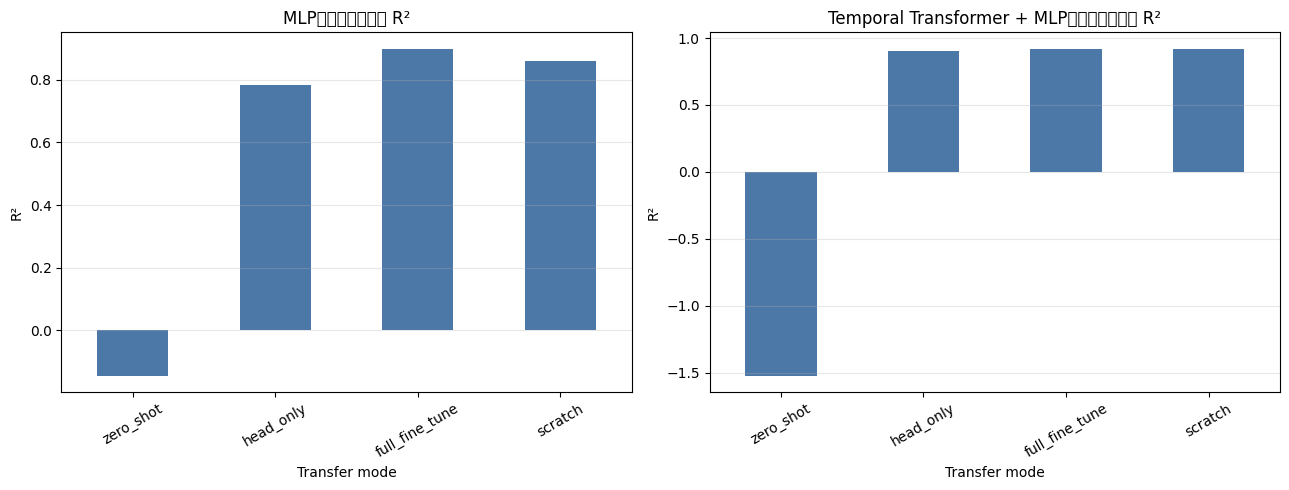

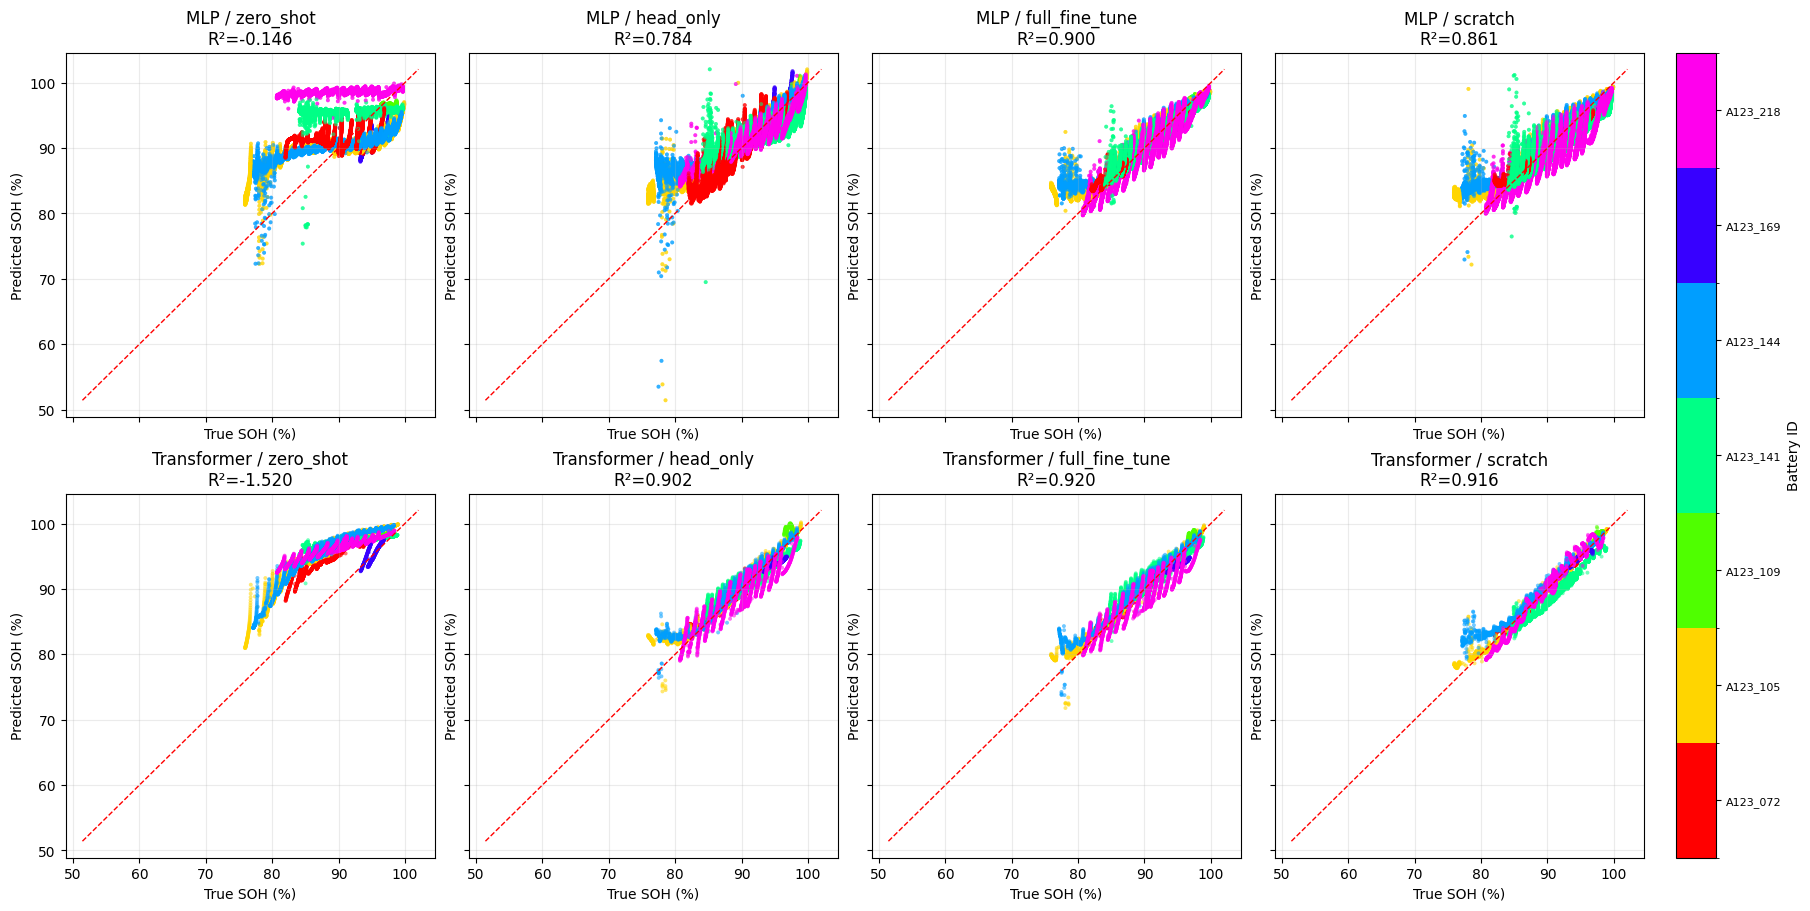

In [118]:
# ==================== 6. 统一对比与可视化 ====================
# Transformer 结果是本单元的唯一必需输入；MLP 结果若存在才加入对比。
if 'temporal_results' not in globals() or 'temporal_summary' not in globals():
    raise RuntimeError('请先运行 Transformer 实验单元，生成 temporal_results 和 temporal_summary。')
has_mlp_results = (
    'mlp_results' in globals() and 'mlp_summary' in globals()
    and isinstance(mlp_results, dict) and len(mlp_results) > 0
)
summary_frames = []
result_groups = []
if has_mlp_results:
    summary_frames.append(mlp_summary.assign(model='MLP'))
    result_groups.append(('MLP', mlp_results))
summary_frames.append(temporal_summary.assign(model='Temporal Transformer + MLP'))
result_groups.append(('Temporal Transformer + MLP', temporal_results))
comparison = pd.concat(summary_frames).reset_index().rename(columns={'index': 'transfer_mode'}).set_index(['model', 'transfer_mode'])
print(comparison.round(4).to_string())

# 将测试真值、预测值和电池编号统一保存，保证颜色与数据顺序严格对应。
model_results = {}
if has_mlp_results:
    for mode, result in mlp_results.items():
        model_results[f'MLP / {mode}'] = {'y_true': y_test, 'y_pred': result['mean'], 'battery_ids': result['battery_ids']}
for mode in TEMPORAL_MODES:
    model_results[f'Transformer / {mode}'] = {'y_true': y_seq_test, 'y_pred': temporal_results[mode]['mean'], 'battery_ids': temporal_results[mode]['battery_ids']}

def battery_error_table(y_true, y_pred, battery_ids):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    battery_ids = np.asarray(battery_ids).astype(str).ravel()
    if not (len(y_true) == len(y_pred) == len(battery_ids)):
        raise ValueError('y_true、y_pred 和 battery_ids 长度必须一致。')
    detail = pd.DataFrame({'battery_id': battery_ids, 'y_true': y_true, 'y_pred': y_pred})
    detail['error'] = detail['y_pred'] - detail['y_true']
    detail['abs_error'] = detail['error'].abs()
    detail['squared_error'] = detail['error'] ** 2
    summary = (detail.groupby('battery_id', sort=True)
        .agg(n=('error', 'size'), MAE=('abs_error', 'mean'), RMSE=('squared_error', lambda values: float(np.sqrt(np.mean(values)))), Bias=('error', 'mean'), MaxAbsError=('abs_error', 'max'))
        .reset_index().sort_values(['MAE', 'RMSE'], ascending=[False, False], kind='stable').reset_index(drop=True))
    return detail, summary

battery_error_tables = {}
error_summary_frames = []
for title, item in model_results.items():
    detail, summary = battery_error_table(item['y_true'], item['y_pred'], item['battery_ids'])
    battery_error_tables[title] = {'detail': detail, 'summary': summary}
    error_summary_frames.append(summary.assign(model=title))
    print(f'\n{title}：误差最大的 10 块电池（按 MAE 排序）')
    display(summary.head(10).round(4))
battery_error_summary = pd.concat(error_summary_frames, ignore_index=True)
battery_mae_matrix = battery_error_summary.pivot(index='battery_id', columns='model', values='MAE')
battery_mae_matrix['平均 MAE'] = battery_mae_matrix.mean(axis=1)
print('\n所有模型的按电池 MAE 对比（平均 MAE 越大，整体误差越大）')
display(battery_mae_matrix.sort_values('平均 MAE', ascending=False).round(4))

fig, axes = plt.subplots(1, len(result_groups), figsize=(6.5 * len(result_groups), 5), squeeze=False)
axes = axes.ravel()
for ax, (title, result_dict) in zip(axes, result_groups):
    table = pd.DataFrame({m: r['metrics'] for m, r in result_dict.items()}).T
    table['r2'].plot(kind='bar', ax=ax, color='#4C78A8')
    ax.set_title(f'{title}：目标域测试集 R²'); ax.set_xlabel('Transfer mode'); ax.set_ylabel('R²'); ax.tick_params(axis='x', rotation=30); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

all_batteries = sorted({str(bid) for item in model_results.values() for bid in item['battery_ids']})
if not all_batteries:
    raise RuntimeError('测试集没有可用于着色的电池编号。')
battery_to_code = {battery_id: code for code, battery_id in enumerate(all_batteries)}
cmap = ListedColormap(plt.cm.hsv(np.linspace(0, 1, len(all_batteries), endpoint=False)))
norm = BoundaryNorm(np.arange(len(all_batteries) + 1) - 0.5, len(all_batteries))

n_plots = len(model_results)
n_cols = min(4, n_plots)
n_rows = int(np.ceil(n_plots / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 4.5 * n_rows), sharex=True, sharey=True, constrained_layout=True, squeeze=False)
axes = np.asarray(axes).ravel()
all_values = np.concatenate([np.asarray(v, dtype=float).ravel() for item in model_results.values() for v in (item['y_true'], item['y_pred'])])
lo, hi = float(np.nanmin(all_values)), float(np.nanmax(all_values))
for ax, (title, item) in zip(axes, model_results.items()):
    ids = np.asarray(item['battery_ids']).astype(str)
    color_codes = np.array([battery_to_code[bid] for bid in ids], dtype=int)
    ax.scatter(item['y_true'], item['y_pred'], c=color_codes, cmap=cmap, norm=norm, s=8, alpha=0.55, linewidths=0)
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1)
    comparison_model = 'MLP' if title.startswith('MLP') else 'Temporal Transformer + MLP'
    ax.set_title(f"{title}\nR²={comparison.loc[(comparison_model, title.split(' / ', 1)[-1]), 'r2']:.3f}")
    ax.set_xlabel('True SOH (%)'); ax.set_ylabel('Predicted SOH (%)'); ax.grid(alpha=0.25)
for ax in axes[len(model_results):]:
    ax.set_axis_off()
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), pad=0.02)
cbar.set_ticks(np.arange(len(all_batteries))); cbar.set_ticklabels(all_batteries); cbar.set_label('Battery ID'); cbar.ax.tick_params(labelsize=8)
plt.show()

## 7. 保存目标域迁移模型

四组实验都会保存，并同时保存 scaler、特征顺序、窗口配置和评估结果。

In [119]:
# ==================== 7. 保存全部迁移产物 ====================
TRANSFER_SAVE_DIR = Path("./target_transfer_artifacts")
TRANSFER_SAVE_DIR.mkdir(parents=True, exist_ok=True)


def cpu_state(model):
    return {key: value.detach().cpu() for key, value in model.state_dict().items()}


def save_ensemble(models, path):
    torch.save({f"member_{index}": cpu_state(model) for index, model in enumerate(models)}, path)


common_metadata = {
    "excluded_target_dods": sorted(excluded_dods),
    "excluded_target_cell_ids": sorted(excluded_cell_ids),
    "excluded_target_cell_ids_present": excluded_cell_ids_present,
    "remaining_target_dods": remaining_target_dods,
    "excluded_target_condition_keys": excluded_condition_keys,
    "target_train_cells": target_train_cells.tolist(),
    "target_val_cells": sorted(val_cells),
    "target_test_cells": sorted(test_cells),
    "batteries_per_condition": BATTERIES_PER_CONDITION,
    "selected_condition_count": int(selection_diagnostics["condition_key"].nunique()),
    "selected_cell_count": int(len(target_train_cells)),
    "total_target_cell_count": int(data["cell_id"].nunique()),
    "raw_target_cell_count": raw_target_cell_count,
    "selected_condition_batteries": selected_assignments.to_dict("records"),
}


for mode, result in mlp_results.items():
    save_ensemble(result["models"], TRANSFER_SAVE_DIR / f"mlp_{mode}.pt")
    joblib.dump(
        {
            "features": FEATURES,
            "target": TARGET,
            "use_log_tau": USE_LOG_TAU,
            "log_tau_cols": LOG_TAU_COLS,
            "hidden": MLP_HIDDEN,
            "p_drop": MLP_DROPOUT,
            "in_dim": MLP_IN_DIM,
            "mode": mode,
            "x_scaler": result["x_scaler"],
            "y_scaler": result["y_scaler"],
            "metrics": result["metrics"],
            "training_histories": result.get("histories"),
            **common_metadata,
        },
        TRANSFER_SAVE_DIR / f"mlp_{mode}_pre.joblib",
    )

for mode, result in temporal_results.items():
    save_ensemble(result["models"], TRANSFER_SAVE_DIR / f"temporal_transformer_{mode}.pt")
    joblib.dump(
        {
            "features": FEATURES,
            "target": TARGET,
            "seq_len": SEQ_LEN,
            "seq_stride": SEQ_STRIDE,
            "sequence_unit": SEQUENCE_UNIT,
            "d_model": TEMPORAL_D_MODEL,
            "nhead": TEMPORAL_NHEAD,
            "num_layers": TEMPORAL_NUM_LAYERS,
            "dim_ff": TEMPORAL_DIM_FF,
            "p_drop": TEMPORAL_DROPOUT,
            "mode": mode,
            "seq_scaler": result["x_scaler"],
            "seq_y_scaler": result["y_scaler"],
            "metrics": result["metrics"],
            "training_histories": result.get("histories"),
            **common_metadata,
        },
        TRANSFER_SAVE_DIR / f"temporal_transformer_{mode}_pre.joblib",
    )

comparison.to_csv(TRANSFER_SAVE_DIR / "transfer_comparison.csv")
battery_error_summary.to_csv(TRANSFER_SAVE_DIR / "battery_error_summary.csv", index=False, encoding="utf-8-sig")
print(f"已保存到：{TRANSFER_SAVE_DIR.resolve()}")


已保存到：C:\Users\huang\Downloads\target_transfer_artifacts


## 8. MLP 推理示例

新的行级样本必须包含与 FEATURES 相同的列，并执行相同的 log 变换和 scaler。

In [120]:
# ==================== 8. 加载迁移后的 MLP 并推理 ====================
def load_saved_mlp(mode="full_fine_tune"):
    ckpt = safe_torch_load(TRANSFER_SAVE_DIR / f"mlp_{mode}.pt")
    pre = joblib.load(TRANSFER_SAVE_DIR / f"mlp_{mode}_pre.joblib")
    return [build_mlp(s) for s in member_states(ckpt)], pre

def predict_mlp_rows(new_frame, mode="full_fine_tune"):
    models, pre = load_saved_mlp(mode); frame = canonicalize_columns(new_frame)
    missing = [c for c in FEATURES if c not in frame.columns]
    if missing: raise KeyError(f"推理数据缺少特征列：{missing}")
    values = frame[FEATURES].apply(pd.to_numeric, errors="coerce")
    if USE_LOG_TAU:
        for col in LOG_TAU_COLS: values[col] = np.log(values[col])
    if values.isna().any().any(): raise ValueError("推理特征存在空值或无法转换为数值的值")
    X_new = pre["x_scaler"].transform(values.to_numpy(np.float32)).astype(np.float32)
    return mlp_predict(models, X_new, pre["y_scaler"])

# 示例：
# new_rows = pd.read_csv("your_new_target_rows.csv")
# pred_mean, pred_std = predict_mlp_rows(new_rows, mode="full_fine_tune")